# Lab 4: A team of agents: specialists, a reviewer, a supervisorn

Yesterday one agent held every tool. Today the same job is done by a **team**: a triage agent that decides who is needed, a policy specialist and an account specialist that each know one thing well, a writer, a **reviewer who is not the writer**, and a supervisor that fixes the order, enforces a budget and knows when to hand a case to a person.

```
message ─▶ triage ─▶ which specialists? ─▶ policy specialist (Lab 1: retrieval)  ─┐
                    │                       account specialist (Lab 2: SQL)         ├─▶ case file ─▶ writer ─▶ reviewer ──returned──▶ writer again, or a specialist again
                    └─ escalate now ─▶ a person                                     ┘                                └──approved──▶ the reply      ──refused twice──▶ a person
```

Then the honest question: **is the team better than one agent with all the tools?** The same three cases go through both, judged by the same reviewer, and a table shows what each path cost and what it got right. That trade-off is the decision every capstone team makes this afternoon.

### Setup: Runtime → Change runtime type → **T4 GPU**, then run this cell

In [1]:
!pip install -q -U transformers accelerate chromadb sentence-transformers pypdf

import torch, json, re
from transformers import AutoTokenizer, AutoModelForImageTextToText

MODEL_ID = "Qwen/Qwen3.5-4B"          # 4B open model, ~9 GB in fp16, fits a free T4. (Fallback: "Qwen/Qwen3-4B")
tok = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(MODEL_ID, dtype=torch.float16, device_map="auto")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 586.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

config.json:   0%|          | 0.00/3.16k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

...

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/76.2k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

In [2]:
def chat(messages, max_new_tokens=400, temperature=0.0):
    """The one function that talks to the model: a prompt string or a list of {role, content} -> reply text."""
    if isinstance(messages, str):
        messages = [{"role": "user", "content": messages}]
    prompt = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=False)
    inputs = tok(prompt, return_tensors="pt").to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=temperature > 0,
                         temperature=temperature if temperature > 0 else None)
    return tok.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

In [3]:
print(chat("Say hello in five words."))

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.
[transformers] `causal_conv1d_update` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.
[transformers] `fused_recurrent_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.


Hello there, friend. How are you?


## 1: The cases and the case file

Five customer messages from the Brightwave story. The **case file** is a plain dictionary: every agent reads it and writes its own part. That one rule is what makes a team readable afterwards: the file *is* the conversation, and the trace says who touched it and what it cost.

In [4]:
import time, sqlite3, pandas as pd

MESSAGES = {
"amina": """From: Amina Hassan
Subject: Credit balance refund

My account has been in credit for four months and I would like the money back rather than leaving it on the account.
I pay by direct debit and I sent a meter reading on 2 September.""",
"tom": """From: Tom Okafor
Subject: Missed smart meter appointment

Nobody came for the smart meter installation on Tuesday and no one called. I took the whole morning off work for it.
Please tell me what compensation I am owed and book a new slot.""",
"bayo": """From: Bayo Adeyemi
Subject: Complaint about waiting times

I have called four times this month and waited over forty minutes each time before giving up.
I want the goodwill payment you promised in July and never paid, and I want this treated as a formal complaint.""",
"sofia": """From: Sofia Pereira
Subject: Refund after moving out

I moved out of the flat on 14 August and gave a closing reading the same day. The final statement shows I am owed 62 pounds.
Three weeks later there is still no refund in my bank account.""",
"thanks": """From: Grace Osei
Subject: Thank you

Just a quick note to say the engineer yesterday was brilliant. Sorted the meter in twenty minutes. Thank you!""",
}

def new_case(message):
    """The shared case file. Every agent reads it and writes its own part; agents never talk to each other directly."""
    return {"message": message, "customer": re.search(r"^From:\s*(.+)$", message, re.M).group(1).strip(),
            "kind": None, "urgency": None, "needs": [], "escalate": False, "findings": {}, "draft": None, "review": None, "rounds": 0}

TRACE = []

def record(case, agent, note, started, calls):
    """Print what an agent did, and keep it: this trace is how the run is read afterwards."""
    TRACE.append({"customer": case["customer"], "agent": agent, "model calls": calls, "seconds": round(time.time() - started, 1)})
    print(f"\n{'━' * 72}\n {agent.upper():<10} {case['customer']}  ·  {calls} call{'s' if calls != 1 else ''}, {time.time() - started:.0f}s\n{'━' * 72}\n{note}")

print(MESSAGES["tom"])

From: Tom Okafor
Subject: Missed smart meter appointment

Nobody came for the smart meter installation on Tuesday and no one called. I took the whole morning off work for it.
Please tell me what compensation I am owed and book a new slot.


## 2: What the specialists know

The six Brightwave policies from Day 1, indexed for search exactly as in Lab 1, and a ten-customer table in SQLite for the account specialist to query exactly as in Lab 2. Two specialists, two knowledge sources, and neither can see the other's.

In [5]:
# Six short internal documents of "Brightwave Energy", a fictional UK supplier with a Dublin office.
DOCS = [
 {"id": "refund_policy", "region": "UK", "text": """Credit balance refunds: customers who pay by direct debit can request a refund of their credit balance
at any time. Approved refunds are paid within 10 working days to the original payment method. Refunds above GBP 250 must first be
reviewed by the Billing team, who confirm an up-to-date meter reading. Duplicate payments are refunded in full within 5 working days.
Customers on the Priority Services Register are fast-tracked and paid within 5 working days."""},
 {"id": "complaints", "region": "UK", "text": """Complaints: we acknowledge every complaint within 2 working days and aim to resolve it within
10 working days. If a complaint is still open after 8 weeks, the customer may go to the Energy Ombudsman and we must tell them so in
writing. Frontline staff may offer goodwill payments up to GBP 50; larger amounts need a team leader."""},
 {"id": "smart_meter", "region": "UK", "text": """Smart meter installation: appointments are free, take 60-90 minutes and use 4-hour windows,
Monday to Saturday. Cancelling or moving an appointment is free up to 48 hours before. If our engineer misses an appointment without one
working day's notice, the customer receives GBP 30 compensation automatically within 10 working days."""},
 {"id": "leave_uk", "region": "UK", "text": """Annual leave, United Kingdom: full-time employees receive 25 days plus bank holidays. The leave year
runs January to December. Up to 5 unused days may be carried over into the next year and must be used by 31 March or they are lost."""},
 {"id": "leave_ireland", "region": "IE", "text": """Annual leave, Ireland: full-time employees in the Dublin office receive 22 days plus public
holidays. The leave year runs January to December. Up to 8 unused days may be carried over into the next year and must be used by 30 April."""},
 {"id": "escalation", "region": "ALL", "text": """Escalation rules for assistants: any mention of a gas smell or a safety risk -> give the National
Gas Emergency number 0800 111 999 and hand over to a human immediately. Refunds above GBP 250 -> hand over to Billing. Complaints open
for more than 8 weeks, legal threats, or a third contact about the same issue -> hand over to the Complaints team. Never disclose bank
details, passwords or another person's data."""},
]


import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

embedder = SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2", device="cuda")
policies = chromadb.Client().create_collection("policies", embedding_function=embedder, metadata={"hnsw:space": "cosine"})
policies.add(ids=[d["id"] for d in DOCS], documents=[d["text"] for d in DOCS], metadatas=[{"source": d["id"]} for d in DOCS])

CUSTOMERS = pd.DataFrame([
 ("BW-1001", "Amina Hassan",     "London",     "Fixed 12",  86.40, 4, 0, 0, 1, "2025-09-02", "pays by direct debit"),
 ("BW-1002", "Tom Okafor",       "Midlands",   "Variable", -12.10, 0, 0, 0, 1, "2025-08-28", "smart meter install booked 9 Sep: engineer did not attend, no notice given"),
 ("BW-1003", "Erik Lindqvist",   "Scotland",   "Variable", -151.00, 0, 0, 0, 1, "2025-07-30", "Aug bill 74.00, Sep bill 151.00; Sep used an estimated reading"),
 ("BW-1004", "Sofia Pereira",    "London",     "Fixed 12",  61.50, 1, 0, 0, 2, "2025-08-14", "moved out 14 Aug; final statement issued 20 Aug; refund not yet paid"),
 ("BW-1005", "Claire Donnelly",  "North West", "Green Plus", -40.20, 0, 0, 0, 1, "2025-09-04", "smart meter fitted 1 Sep"),
 ("BW-1006", "Hannah Whitfield", "North West", "Fixed 24",  -33.00, 0, 0, 0, 1, "2025-09-01", "fixed tariff ends 2026-03-31"),
 ("BW-1007", "Bayo Adeyemi",     "Midlands",   "Variable",  -58.75, 0, 0, 1, 4, "2025-08-20", "goodwill payment of 40.00 promised 15 Jul, not paid"),
 ("BW-1008", "Petra Novak",      "Scotland",   "Fixed 12",  -21.00, 0, 0, 0, 2, "2025-08-30", "third-floor flat; two install visits declined by engineer"),
 ("BW-1009", "Lewis Campbell",   "Scotland",   "Variable",  12.00, 1, 1, 0, 0, "2025-09-01", "on the Priority Services Register"),
 ("BW-1010", "Grace Osei",       "London",     "Green Plus", -18.40, 0, 0, 0, 1, "2025-09-10", "smart meter fitted 10 Sep"),
], columns=["customer_id", "name", "region", "tariff", "balance_gbp", "months_in_credit", "priority_services", "open_complaints", "contacts_this_month", "last_reading", "notes"])

conn = sqlite3.connect(":memory:")
CUSTOMERS.to_sql("customers", conn, index=False)
SCHEMA = "customers(" + ", ".join(CUSTOMERS.columns) + ")  -- balance_gbp > 0 means the customer is in credit"
print(len(DOCS), "policies indexed ·", len(CUSTOMERS), "customers in SQLite")
CUSTOMERS[["customer_id", "name", "balance_gbp", "contacts_this_month", "notes"]].head(4)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

6 policies indexed · 10 customers in SQLite


,customer_id,name,balance_gbp,contacts_this_month,notes
0,BW-1001,Amina Hassan,86.4,1,pays by direct debit
1,BW-1002,Tom Okafor,-12.1,1,smart meter install booked 9 Sep: engineer did...
2,BW-1003,Erik Lindqvist,-151.0,1,"Aug bill 74.00, Sep bill 151.00; Sep used an e..."
3,BW-1004,Sofia Pereira,61.5,2,moved out 14 Aug; final statement issued 20 Au...


## Step 1: Triage — the router

The first decision on every case: what kind of case, how urgent, **which specialists it needs**, and whether a person must take it now. The escalation rules come straight from the policy, so the model is applying them, not inventing them. A message that needs nobody should cost nothing more than this one call.

In [6]:
def chat_json(messages, **kw):
    """Same as chat(), but returns the first JSON object found in the reply as a dict."""
    text = chat(messages, **kw)
    start = text.find("{")
    try:
        return json.JSONDecoder().raw_decode(text[start:])[0] if start >= 0 else {}   # ignore anything after the object
    except json.JSONDecodeError:
        return {}                                                                      # a truncated or broken reply -> no decision

In [7]:
def triage(case):
    """Read the message; decide what kind of case it is, who is needed, and whether a person must take it now."""
    started = time.time()
    reply = chat_json(f"You triage customer messages for an energy supplier. Two specialists exist: 'policy' knows what our rules allow, "
                      f"'account' can look up the customer's record. Only list a specialist if this message needs it; a thank-you needs neither.\n\n"
                      f"Escalate straight to a person only for: a gas smell or safety risk, a legal threat, or a customer whose message says this is "
                      f"their third or later contact about the same issue. Everything else, refunds and complaints included, stays with the team.\n\n"
                      f"Message:\n{case['message']}\n\n"
                      f'Return JSON: {{"kind": "refund | appointment | billing | complaint | other", "urgency": "low | normal | high", '
                      f'"needs": [...], "escalate": true/false, "why": "one sentence"}}')
    case.update(kind=reply.get("kind"), urgency=reply.get("urgency"), escalate=str(reply.get("escalate")).lower() == "true",
                needs=[n for n in reply.get("needs", []) if n in ("policy", "account")])
    record(case, "triage", f"{case['kind']} · {case['urgency']} · needs {case['needs'] or 'nobody'}"
           + ("  →  ESCALATE: " if case["escalate"] else "  ·  ") + str(reply.get("why", "")), started, calls=1)
    return case

for key in ("amina", "bayo", "thanks"):
    triage(new_case(MESSAGES[key]))


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 TRIAGE     Amina Hassan  ·  1 call, 5s
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
refund · low · needs ['account']  ·  The customer is requesting a refund for a credit balance, which is a standard billing matter handled by the team without safety risks or repeated contact flags.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 TRIAGE     Bayo Adeyemi  ·  1 call, 5s
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
complaint · normal · needs ['account']  ·  The customer is requesting a formal complaint and a promised payment, which falls under standard team handling despite the high call volume.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 TRIAGE     Grace Osei  ·  1 call, 4s
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
other · low · needs nobody  ·  This is a thank-you message 

## Step 2: The specialists

Each specialist has one job, one knowledge source and one short prompt. The **policy specialist** retrieves the two most relevant passages and states what they allow, with the source in brackets after every fact. The **account specialist** writes one SQL query, runs it, and repairs it once if the database objects, which is Lab 2's loop in eight lines. Both write their findings into the case file and nothing else.

Notice what they do not see. The policy specialist never sees the account. The account specialist never sees the policy. Small prompts, no cross-contamination, and a finding that can be traced to its source.

In [8]:
def policy_specialist(case, question=None):
    """What do our rules allow for this case? Two passages in, a short cited finding out."""
    started = time.time()
    r = policies.query(query_texts=[question or case["message"]], n_results=2)
    passages = "\n\n".join(f"[{m['source']}] {d}" for d, m in zip(r["documents"][0], r["metadatas"][0]))
    finding = chat(f"Policy passages:\n{passages}\n\nCustomer message:\n{case['message']}\n\n"
                   + (f"Specific question from the reviewer: {question}\n\n" if question else "")
                   + f"In 2-4 short sentences, state exactly what the policy allows or requires for this case, quoting every amount and timeframe, "
                   f"with the source id in square brackets after each fact. If the passages do not cover it, say so plainly.", max_new_tokens=220)
    case["findings"]["policy"] = finding
    record(case, "policy", finding, started, calls=1)
    return case

def account_specialist(case, question=None):
    """What does the customer's record show? One SQL query, repaired once if it fails."""
    started, calls, sql, error = time.time(), 0, None, None
    ask = question or "everything on this customer's record that matters for their message: " + case["message"].splitlines()[1]
    for attempt in range(2):
        reply = chat(f"Write one SQLite SELECT over the table {SCHEMA}.\nThe customer is {case['customer']!r}.\nQuestion: {ask}\n"
                     + (f"\nYour previous query:\n{sql}\nfailed with: {error}\nWrite a corrected query.\n" if error else "")
                     + "Reply with the SQL in a ```sql block.", max_new_tokens=150); calls += 1
        block = re.search(r"```sql\s*(.*?)```", reply, re.S | re.I)
        sql = (block.group(1) if block else reply).strip().rstrip(";")
        try:
            rows = pd.read_sql(sql, conn); break
        except Exception as e:
            error, rows = str(e).splitlines()[-1], None
    finding = rows.to_string(index=False) if rows is not None and len(rows) else f"could not read the account ({error or 'no matching record'})"
    case["findings"]["account"] = finding
    record(case, "account", f"{sql}\n\n{finding}", started, calls=calls)
    return case

SPECIALISTS = {"policy": policy_specialist, "account": account_specialist}

case = triage(new_case(MESSAGES["amina"]))
for name in case["needs"]:
    case = SPECIALISTS[name](case)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 TRIAGE     Amina Hassan  ·  1 call, 4s
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
refund · low · needs ['account']  ·  The customer is requesting a refund for a credit balance, which is a standard billing matter handled by the team without safety risks or repeated contact flags.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ACCOUNT    Amina Hassan  ·  1 call, 4s
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SELECT name, balance_gbp, priority_services, open_complaints, contacts_this_month, last_reading, notes
FROM customers
WHERE name = 'Amina Hassan'

        name  balance_gbp  priority_services  open_complaints  contacts_this_month last_reading                notes
Amina Hassan         86.4                  0                0                    1   2025-09-02 pays by direct debit


## Step 3: The writer

The writer sees the message and the specialists' findings, and is told to use **only** facts, amounts and timeframes from those findings. It will not always obey. That is what the next agent is for.

In [9]:
def writer(case, reasons=None):
    """Draft the reply from the case file. On a second round it also sees why the reviewer returned the last one."""
    started = time.time()
    findings = "\n\n".join(f"{name.upper()} SPECIALIST FOUND:\n{text}" for name, text in case["findings"].items()) or "No specialist findings."
    draft = chat(f"Write a reply to this customer on behalf of Brightwave Energy.\n\nCustomer message:\n{case['message']}\n\n{findings}\n\n"
                 f"Rules: use only facts, amounts and timeframes that appear in the specialists' findings, and nothing from memory; "
                 f"acknowledge the issue, say exactly what happens next and by when; under 120 words; plain and warm; "
                 f"sign off as 'Brightwave Customer Team'."
                 + (f"\n\nThe reviewer returned your previous draft:\n{case['draft']}\n\nbecause:\n" + "\n".join("- " + r for r in reasons)
                    + "\n\nFix every point." if reasons else ""), max_new_tokens=260)
    case["draft"] = draft
    record(case, "writer", draft, started, calls=1)
    return case

case = writer(case)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 WRITER     Amina Hassan  ·  1 call, 10s
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Dear Amina,

Thank you for contacting Brightwave. We acknowledge your request to receive your £86.40 credit balance refund instead of keeping it on your account.

Since you pay by direct debit, we will process this refund immediately. You should receive the funds back into your original payment method within 14 days.

We appreciate your patience and are here to help.

Brightwave Customer Team


## Step 4: The reviewer — a critic who is not the author

Half the checklist is code, half is the model, same split as every lab so far. Code checks that **every amount and timeframe in the draft appears in a specialist's finding**, that nothing is promised the policy does not allow, and that the reply is not too long. The model checks whether the draft actually answers what the customer asked, in the right tone. If a fact is missing, the reviewer names the specialist who should be asked again and the question to ask.

The verdict goes into the case file. The reviewer does not fix anything; that is the writer's job.

In [10]:
BANNED = ["guarantee", "immediately", "straight away", "as a gesture we will", "we will definitely"]

def reviewer(case):
    """Approve the draft, or return it with reasons. Code checks the facts, the model checks the sense."""
    started = time.time()
    draft, evidence = case["draft"], " ".join(case["findings"].values())
    amounts = {f"{float(n.replace(',', '')):g}" for n in re.findall(r"£\s?(\d[\d,]*(?:\.\d+)?)", draft)
               + re.findall(r"\b(\d+(?:\.\d+)?)\s*(?:pounds|GBP)\b", draft)}                                  # money the draft promises
    known = {f"{float(n.replace(',', '')):g}" for n in re.findall(r"\d[\d,]*(?:\.\d+)?", evidence)}         # every number a specialist reported
    problems = [f"£{n} is not in any specialist's findings" for n in sorted(amounts - known)]
    for span, n, unit in re.findall(r"\b((\d+)\s*(?:working\s+)?(day|hour|week|month)s?)\b", draft):                 # timeframes the draft states
        if f"{float(n):g}" not in known or unit not in evidence.lower():
            problems.append(f"'{span}' is not in any specialist's findings")
    problems += [f"promises '{p}'" for p in BANNED if p in draft.lower()]
    if len(draft.split()) > 150:
        problems.append(f"{len(draft.split())} words, the limit is 150")
    verdict = chat_json(f"You review replies before they reach customers.\n\nCustomer message:\n{case['message']}\n\nWhat the specialists found:\n{evidence}\n\n"
                        f"Draft reply:\n{draft}\n\nDoes the draft answer what the customer actually asked, in a plain and warm tone, without stating "
                        f"anything the findings do not support? If a needed fact is missing, name the specialist to ask ('policy' or 'account') and the question.\n"
                        f'Return JSON: {{"approved": true/false, "reasons": ["..."], "ask_again": [], "question": ""}}', max_new_tokens=250)
    approved = not problems and str(verdict.get("approved")).lower() == "true"
    reasons = [] if approved else problems + [str(r) for r in verdict.get("reasons", []) if r]
    case["review"] = {"approved": approved, "reasons": reasons, "question": str(verdict.get("question") or ""),
                      "ask_again": [a for a in (verdict.get("ask_again") or []) if a in SPECIALISTS]}
    record(case, "reviewer", "APPROVED" if approved else "RETURNED\n" + "\n".join("- " + r for r in reasons)
           + (f"\n→ ask {case['review']['ask_again']}: {case['review']['question']}" if case["review"]["ask_again"] else ""), started, calls=1)
    return case

case = reviewer(case)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 REVIEWER   Amina Hassan  ·  1 call, 27s
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
RETURNED
- '14 days' is not in any specialist's findings
- promises 'immediately'
- The draft states the refund will be processed 'immediately' and received within '14 days', but the specialist notes do not confirm the specific payment method for the refund (e.g., bank transfer vs. direct debit reversal) or the exact timeline, making the 'immediate' claim unsupported.
- The draft mentions the customer pays by direct debit but does not explicitly confirm whether the refund will be issued back to the same direct debit account or a different method, which is a critical detail for the customer's expectation.
→ ask ['account']: 


## Step 5: The supervisor — order, budget, exit

Everything above is a function of the case file. The supervisor decides the order and nothing else: triage, then the specialists triage asked for, then writer and reviewer for at most two rounds. Two things make it an agent system rather than a pipeline: the reviewer can **send a specialist back to work** with a specific question, and there is an **exit to a person**, taken when triage says so or when the reviewer refuses twice. The person receives the whole case file, not a summary.

In [11]:
RESULTS = {}                                                                       # customer -> how the team's run ended

def hand_to_human(case, why):
    RESULTS[case["customer"]] = {"approved": False, "reasons": len(case["review"]["reasons"]) if case["review"] else 0}
    print(f"\n{'#' * 72}\n TO A PERSON: {case['customer']} — {why}\n{'#' * 72}")
    print(f"kind: {case['kind']} · urgency: {case['urgency']}\nfindings: {list(case['findings'])}\nlast draft: {(case['draft'] or 'none')[:300]}"
          f"\nreviewer said: {case['review']['reasons'] if case['review'] else '-'}")
    return case

def handle(message, max_rounds=2):
    """The supervisor: triage, dispatch, write, review, loop back, or hand over."""
    case = triage(new_case(message))
    if case["escalate"]:
        return hand_to_human(case, "triage flagged it")
    for name in case["needs"]:
        case = SPECIALISTS[name](case)
    reasons = None
    for round_no in range(1, max_rounds + 1):
        case["rounds"] = round_no
        case = reviewer(writer(case, reasons))
        if case["review"]["approved"]:
            RESULTS[case["customer"]] = {"approved": True, "reasons": 0}
            print(f"\n{'#' * 72}\n APPROVED for {case['customer']} after {round_no} round{'s' if round_no > 1 else ''}\n{'#' * 72}\n{case['draft']}")
            return case
        reasons = case["review"]["reasons"]
        for name in case["review"]["ask_again"]:                                  # the reviewer sends a specialist back to work
            case = SPECIALISTS[name](case, question=case["review"]["question"])
    return hand_to_human(case, f"the reviewer refused {max_rounds} times")

TRACE.clear()
case = handle(MESSAGES["tom"])


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 TRIAGE     Tom Okafor  ·  1 call, 9s
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
appointment · normal · needs ['account']  ·  The customer is requesting a rescheduled appointment and compensation for a missed service, which falls under standard team handling.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ACCOUNT    Tom Okafor  ·  1 call, 8s
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SELECT name, region, tariff, balance_gbp, months_in_credit, priority_services, open_complaints, contacts_this_month, last_reading, notes
FROM customers
WHERE name = 'Tom Okafor'

      name   region   tariff  balance_gbp  months_in_credit  priority_services  open_complaints  contacts_this_month last_reading                                                                      notes
Tom Okafor Midlands Variable        -12.1                 0        

Read the trace top to bottom: who was called, in what order, what each one cost. Now the other two cases. Bayo's message says he has contacted us four times, and the policy says a third contact goes to the complaints team, so watch triage take the exit before any specialist spends a call.

In [12]:
handle(MESSAGES["amina"])
handle(MESSAGES["bayo"])
pd.DataFrame(TRACE).groupby(["customer", "agent"], sort=False)[["model calls", "seconds"]].sum()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 TRIAGE     Amina Hassan  ·  1 call, 4s
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
refund · low · needs ['account']  ·  The customer is requesting a refund for a credit balance, which is a standard billing matter handled by the team without safety risks or repeated contact flags.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ACCOUNT    Amina Hassan  ·  1 call, 4s
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SELECT name, balance_gbp, priority_services, open_complaints, contacts_this_month, last_reading, notes
FROM customers
WHERE name = 'Amina Hassan'

        name  balance_gbp  priority_services  open_complaints  contacts_this_month last_reading                notes
Amina Hassan         86.4                  0                0                    1   2025-09-02 pays by direct debit

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

model calls  seconds
customer     agent                         
Tom Okafor   triage              1      8.8
             account             1      7.6
             writer              2     24.9
             reviewer            2     25.2
Amina Hassan triage              1      4.4
             account             3      9.6
             writer              2     14.0
             reviewer            2     26.9
Bayo Adeyemi triage              1      4.8
             account             2      7.5
             writer              2     18.8
             reviewer            2     26.0

## The same team as a graph — LangGraph

Everything the supervisor does is control flow over a shared state: run this, then that, branch on a verdict, loop with a budget, exit. That is exactly what a graph library exists to write down. **LangGraph** takes the case file as its state, the six agent functions unchanged as its nodes, and the supervisor's decisions as edges. Nothing about the model changes; the agents still call `chat()`.

What you gain is that the control flow becomes data: it can be drawn, checkpointed after every node, resumed after a human step, and handed to a colleague who has never read `handle()`. What you pay is a dependency and a layer of names. Build it by hand once, as you just did, and the framework stops being magic.

In [16]:
!pip install -q "langgraph>=0.6"

from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class Case(TypedDict, total=False):                                          # the case file, declared as the graph's state
    message: str
    customer: str
    kind: str
    urgency: str
    needs: list
    escalate: bool
    findings: dict
    draft: str
    review: dict
    rounds: int

def specialists_node(case):
    """Run the specialists triage asked for, or the one the reviewer sent back with a question."""
    sent_back = bool(case.get("review")) and bool(case["review"]["ask_again"])
    for name in (case["review"]["ask_again"] if sent_back else case["needs"]):
        case = SPECIALISTS[name](case, question=case["review"]["question"] if sent_back else None)
    return case

def writer_node(case):
    case["rounds"] = case.get("rounds", 0) + 1
    return writer(case, case["review"]["reasons"] if case.get("review") else None)

def done_node(case):
    RESULTS[case["customer"]] = {"approved": True, "reasons": 0}
    print(f"\n{'#' * 72}\n APPROVED for {case['customer']} after {case['rounds']} round(s)\n{'#' * 72}\n{case['draft']}")
    return case

def after_triage(case):
    return "human" if case["escalate"] else "specialists"

def after_review(case, max_rounds=2):                                        # the supervisor's if-statements, as a routing function
    if case["review"]["approved"]:
        return "done"
    if case["rounds"] >= max_rounds:
        return "human"
    return "specialists" if case["review"]["ask_again"] else "writer"

graph = StateGraph(Case)
for name, fn in [("triage", triage), ("specialists", specialists_node), ("writer", writer_node), ("reviewer", reviewer),
                 ("done", done_node), ("human", lambda case: hand_to_human(case, "escalated, or the reviewer refused twice"))]:
    graph.add_node(name, fn)
graph.add_edge(START, "triage")
graph.add_conditional_edges("triage", after_triage, {"human": "human", "specialists": "specialists"})
graph.add_edge("specialists", "writer")
graph.add_edge("writer", "reviewer")
graph.add_conditional_edges("reviewer", after_review, {"done": "done", "human": "human", "writer": "writer", "specialists": "specialists"})
graph.add_edge("done", END)
graph.add_edge("human", END)
team = graph.compile()

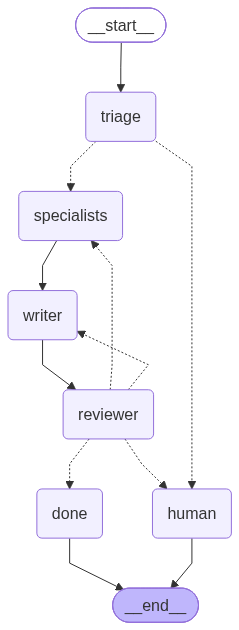

In [17]:
from IPython.display import Image, display
try:
    display(Image(team.get_graph().draw_mermaid_png()))                        # drawn by the library from the edges above
except Exception:
    print(team.get_graph().draw_mermaid())                                     # the same diagram as text, if the renderer is unreachable

In [18]:
TRACE.clear()
final = team.invoke(new_case(MESSAGES["amina"]))                              # same agents, same trace, same cost


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 TRIAGE     Amina Hassan  ·  1 call, 16s
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
refund · low · needs ['account']  ·  The customer is requesting a refund for a credit balance, which is a standard billing matter handled by the team without safety risks or repeated contact flags.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ACCOUNT    Amina Hassan  ·  1 call, 13s
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SELECT name, balance_gbp, priority_services, open_complaints, contacts_this_month, last_reading, notes
FROM customers
WHERE name = 'Amina Hassan'

        name  balance_gbp  priority_services  open_complaints  contacts_this_month last_reading                notes
Amina Hassan         86.4                  0                0                    1   2025-09-02 pays by direct debit

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Exercises & Recap
1. **Parallel specialists.** The policy and account specialists do not depend on each other. Run them concurrently and measure the seconds column.
2. **A second reviewer with a different checklist**, for tone only. Do two critics agree? When they disagree, who wins?

| Agent | Decides | Reuses |
|---|---|---|
| Triage | kind, urgency, who is needed, escalate | the router pattern from your Day 4 deck |
| Policy specialist | what the rules allow, cited | Lab 1's retrieval |
| Account specialist | what the record shows | Lab 2's SQL with repair |
| Writer | the reply, from findings only | |
| Reviewer | approve or return, with a specialist to ask again | code checks the facts, the model checks the sense |
| Supervisor | order, budget, exit to a person | the Interactive lab's approval idea, as an exit |
| The supervisor, drawn | the same six functions as nodes, the verdicts as edges | LangGraph `StateGraph` |
